# Modelo de Hodgkin y Huxley

# Simulación del Modelo de Hodgkin-Huxley

Este notebook tiene como objetivo simular el modelo clásico de Hodgkin-Huxley para una neurona y observar de manera numérica cómo se comporta una célula antes diferentes protocolos de simulación. El modelo de Hodgkin-Huxley describe la dinámica de la membrana neuronal utilizando ecuaciones diferenciales que capturan la evolución de variables de estado como el potencial de membrana y las conductancias de los canales iónicos.

### Modelo de Hodgkin-Huxley

Las ecuaciones que describen el modelo son las siguientes:

$
C_m \frac{dV}{dt} = I_{ext} - (I_{Na} + I_K + I_L)
$

donde:
- $ V $ es el potencial de membrana,
- $ C_m $ es la capacidad de la membrana,
- $ I_{ext} $ es la corriente externa aplicada,
- $ I_{Na} $, $ I_K $ y $ I_L $ son las corrientes de sodio, potasio y fuga, respectivamente.

### Corrientes iónicas

Las corrientes $ I_{Na} $, $ I_K $ y $ I_L $ se modelan de la siguiente manera:

$
I_{Na} = \bar{g}_{Na} m^3 h (V - E_{Na})
$
$
I_K = \bar{g}_K n^4 (V - E_K)
$
$
I_L = \bar{g}_L (V - E_L)
$

donde $ \bar{g} $ son las conductancias máximas, $ E $ son los potenciales de equilibrio y $ m $, $ h $, $ n $ son variables de compuerta.

### Variables de compuerta

Las variables $ m $, $ h $, y $ n $ siguen ecuaciones del tipo:

$
\frac{dx}{dt} = \alpha_x (1 - x) - \beta_x x
$

donde $ x $ puede ser $ m $, $ h $ o $ n $, y $ \alpha_x $ y $ \beta_x $ son funciones del potencial de membrana $ V $.

Para este ejercicio use las siguientes definiciones de $\alpha_x$ y $\beta_x$:

$$
\alpha_n = \frac{0.01(V+55)}{1-exp(-(V+55)/10)}
$$

$$
\beta_n = 0.125exp(-(V+65)/80)
$$


$$
\alpha_m = \frac{0.1(V+40)}{1-exp(-(V+40)/10)}
$$

$$
\beta_m = 4exp(-(V+65)/18)
$$

$$
\alpha_h = 0.07exp(-(V+65)/20)
$$

$$
\beta_h = \frac{1}{1+exp(-(V+35)/10)}
$$

así como $C_m = 1\mu/cm^2$, $\bar{g}_{Na} = 120ms/cm^2$, $\bar{g}_K = 36ms/cm^2$, $\bar{g}_L = 0.3 ms/cm^2$, $E_{Na} = 50mV$, $E_K = -77mV$, $E_L = -50mV$.


### Ejercicio 1:
Use un protocolo de estimulación que como el que se muestra en la figura a continuación y reconstruya el mismo gráfico. El protocolo de estimulación consiste en pulsos de 5 milisengundos de amplitud 5 el primero y 25 el segundo. Tenga en cuenta que este gráfico tiene parámetros ligeramente diferentes que hace que el potencial de membrana este movido a $V_{rest} = 0$.

![HH_excercise.png](attachment:HH_excercise.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

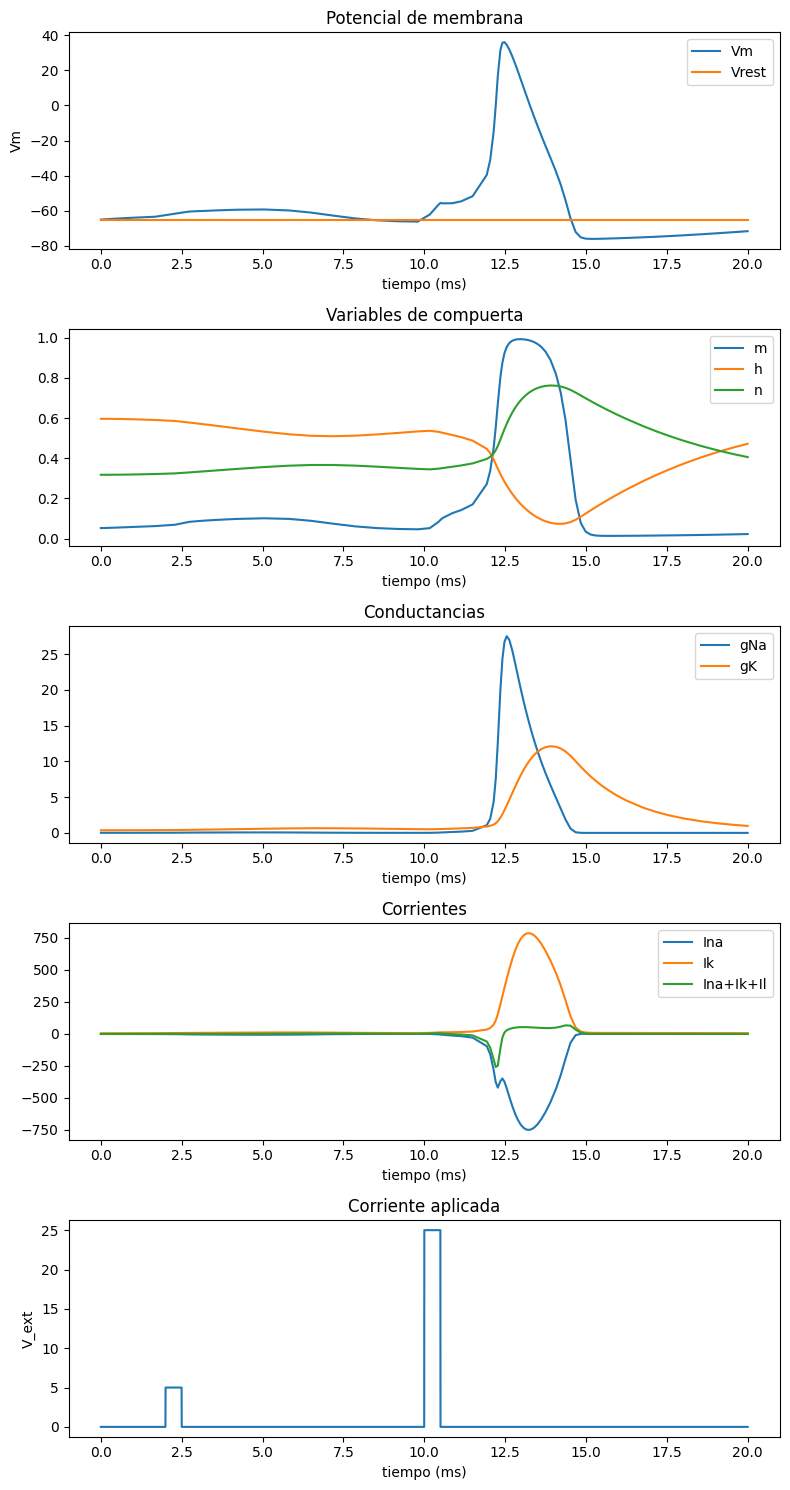

In [2]:
def alpha_n(Vm):
  return 0.01*(Vm+55)/(1-np.exp(-(Vm+55)/10))

def beta_n(Vm):
  return 0.125*np.exp(-(Vm+65)/80)

def alpha_m(Vm):
  return 0.1*(Vm+40)/(1-np.exp(-(Vm+40)/10))

def beta_m(Vm):
  return 4*np.exp(-(Vm+65)/18)

def alpha_h(Vm):
  return 0.07*np.exp(-(Vm+65)/20)

def beta_h(Vm):
  return 1/(1+np.exp(-(Vm+35)/10))

def Ina(Vm, m,h, g_Na, ENa):

  return g_Na*m**3*h*(Vm-ENa)

def Ik(Vm, n, g_K, EK):

  return g_K*n**4*(Vm-EK)

def Il(Vm, g_L, EL):

  return g_L*(Vm-EL)

def Iext(t):
  if t>=2 and t<=2.5:
    return 5
  elif t>=10 and t<=10.5:
    return 25
  else:
    return 0

def HodgkinHuxley(t, X, Cm, g_Na, ENa, g_K, EK, g_L, EL):
    Vm = X[0]
    m = X[1]
    h = X[2]
    n = X[3]

    Vp = (Iext(t) - (Ina(Vm, m, h, g_Na, ENa) + Ik(Vm, n, g_K, EK) + Il(Vm, g_L, EL)))/Cm
    mp = alpha_m(Vm)*(1-m) - beta_m(Vm)*m
    hp = alpha_h(Vm)*(1-h) - beta_h(Vm)*h
    np = alpha_n(Vm)*(1-n) - beta_n(Vm)*n

    return [Vp, mp, hp, np]

# Parámetros:
Cm = 1
tspan = [0,20]
V0 = -65
m0 = alpha_m(V0)/(alpha_m(V0)+beta_m(V0))
h0 = alpha_h(V0)/(alpha_h(V0)+beta_h(V0))
n0 = alpha_n(V0)/(alpha_n(V0)+beta_n(V0))
X0 = [V0,m0,h0,n0]
g_Na = 120 # Conductancia máxima Na
ENa = 50 # Potencial de equilibrio de sodio.
g_K = 36 # Conductancia máxima K
EK = -77 # Potencial de equilibrio de potasio.
g_L = 0.3 # Conductancia máxima L
EL = -50 # Potencial de equilibrio de fuga.



# Calculamos la aproximación
solucion = solve_ivp(HodgkinHuxley,tspan,X0,args=(Cm,g_Na, ENa, g_K, EK, g_L, EL,),dense_output=True)

# Calculamos los resultados.
t = solucion.t
Vm,m,h,n = solucion.y

gNaVec = g_Na*m**3*h
gKVec = g_K*n**4

InaVec = Ina(Vm, m, h, g_Na, ENa)
IkVec = Ik(Vm, n, g_K, EK)
IlVec = Il(Vm, g_L, EL)
Sum_I = InaVec + IkVec + IlVec

# Usemos más puntos en t para mejorar la grafica de la corriente aplicada.
tdenso = np.linspace(tspan[0],tspan[1],5000)
IextVec = np.array([Iext(t_i) for t_i in tdenso])



# Graficamos
plt.figure(figsize=(8,15))
plt.subplot(5,1,1)
plt.plot(t,Vm)
plt.xlabel('tiempo (ms)')
plt.ylabel('Vm')
plt.plot(t,-65*np.ones(len(t)))
plt.title('Potencial de membrana')
plt.legend(['Vm','Vrest'])

plt.subplot(5,1,2)
plt.plot(t,m)
plt.plot(t,h)
plt.plot(t,n)
plt.xlabel('tiempo (ms)')
plt.title('Variables de compuerta')
plt.legend(['m','h','n'])

plt.subplot(5,1,3)
plt.plot(t,gNaVec)
plt.plot(t,gKVec)
plt.xlabel('tiempo (ms)')
plt.title('Conductancias')
plt.legend(['gNa','gK'])

plt.subplot(5,1,4)
plt.plot(t,InaVec)
plt.plot(t,IkVec)
plt.plot(t,Sum_I)
plt.xlabel('tiempo (ms)')
plt.title('Corrientes')
plt.legend(['Ina','Ik','Ina+Ik+Il'])

plt.subplot(5,1,5)
plt.plot(tdenso,IextVec)
plt.xlabel('tiempo (ms)')
plt.title('Corriente aplicada')
plt.ylabel('V_ext')

plt.tight_layout()
plt.show()

## Ejercicio 2:

Repita el ejercicio anterior pero ahora aplique otro pulso de amplitud 25$\mu A/cm^2$ a los 15ms y responda las siguientes preguntas:

1. Qué esperaría observar?
2. Qué observa en cambio esta vez?
3. Investigue por qué se da el periodo refractario

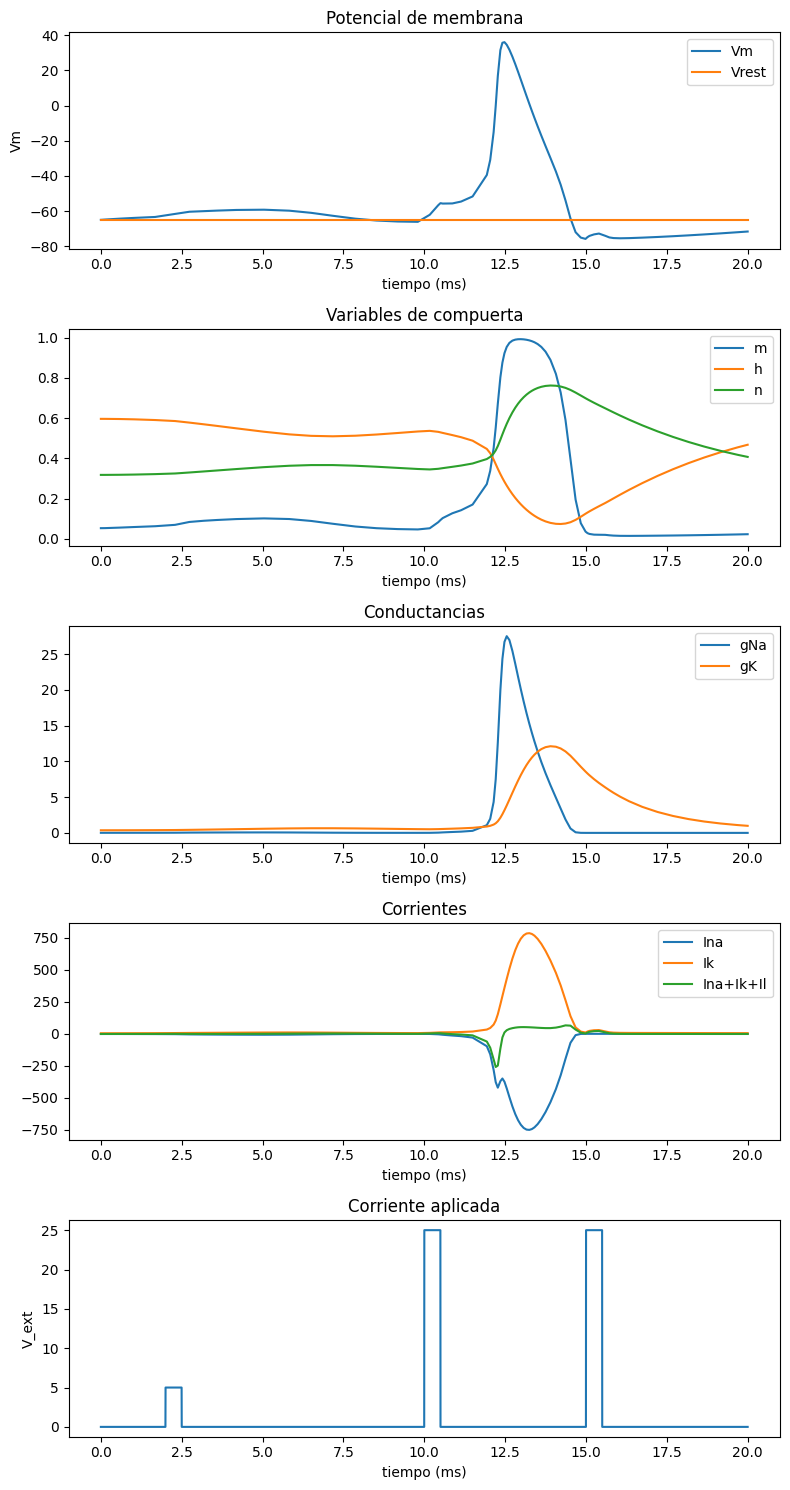

In [3]:
def Iext(t):
  if t>=2 and t<=2.5:
    return 5
  elif t>=10 and t<=10.5:
    return 25
  elif t>=15 and t<=15.5:
    return 25
  else:
    return 0

# Calculamos la aproximación
solucion = solve_ivp(HodgkinHuxley,tspan,X0,args=(Cm,g_Na, ENa, g_K, EK, g_L, EL,),dense_output=True)

# Calculamos los resultados.
t = solucion.t
Vm,m,h,n = solucion.y

gNaVec = g_Na*m**3*h
gKVec = g_K*n**4

InaVec = Ina(Vm, m, h, g_Na, ENa)
IkVec = Ik(Vm, n, g_K, EK)
IlVec = Il(Vm, g_L, EL)
Sum_I = InaVec + IkVec + IlVec

# Usemos más puntos en t para mejorar la grafica de la corriente aplicada.
tdenso = np.linspace(tspan[0],tspan[1],5000)
IextVec = np.array([Iext(t_i) for t_i in tdenso])



# Graficamos
plt.figure(figsize=(8,15))
plt.subplot(5,1,1)
plt.plot(t,Vm)
plt.xlabel('tiempo (ms)')
plt.ylabel('Vm')
plt.plot(t,-65*np.ones(len(t)))
plt.legend(['Vm','Vrest'])
plt.title('Potencial de membrana')

plt.subplot(5,1,2)
plt.plot(t,m)
plt.plot(t,h)
plt.plot(t,n)
plt.xlabel('tiempo (ms)')
plt.legend(['m','h','n'])
plt.title('Variables de compuerta')

plt.subplot(5,1,3)
plt.plot(t,gNaVec)
plt.plot(t,gKVec)
plt.xlabel('tiempo (ms)')
plt.legend(['gNa','gK'])
plt.title('Conductancias')

plt.subplot(5,1,4)
plt.plot(t,InaVec)
plt.plot(t,IkVec)
plt.plot(t,Sum_I)
plt.xlabel('tiempo (ms)')
plt.legend(['Ina','Ik','Ina+Ik+Il'])
plt.title('Corrientes')

plt.subplot(5,1,5)
plt.plot(tdenso,IextVec)
plt.xlabel('tiempo (ms)')
plt.title('Corriente aplicada')
plt.ylabel('V_ext')

plt.tight_layout()
plt.show()

1. Qué esperaría observar?

Dado que la amplitud del pulso en el milisegundo 15 fue la misma que en el milisegundo 10, se esperaría que este estímulo fuera capaz de generar otro spike en la neurona. En el milisegundo 10, la neurona respondió al pulso con un potencial de acción, por lo que, bajo condiciones normales, debería reaccionar de forma similar.

2. Qué observa en cambio esta vez?

En el milisegundo 15, la neurona no genera un spike, a pesar de recibir el mismo estímulo. Esto, por lo visto en clase, se debe a que la neurona se encuentra en su periodo refractario, una fase en la que, tras un spike, su capacidad de respuesta está temporalmente disminuida o bloqueada. Durante esta fase, incluso estímulos que serían efectivos en otro momento no logran superar el umbral para desencadenar un nuevo potencial de acción, y aún con un estimulo muy fuerte la neurona no genera un spike.



3. Investigue por qué se da el periodo refractario

El periodo refractario ocurre debido a las propiedades biofísicas de los canales iónicos, especialmente los de sodio y potasio, en la membrana neuronal. Después de un spike, los canales de sodio entran en un estado de inactivación, lo que impide que un nuevo flujo de sodio ocurra y se produzca otro potencial de acción inmediatamente. Hay dos clasificaciones de este periodo refractario, una llamada el periodo refractario absoluto, en donde no se puede generar un spike sin importar la intensidad del estímulo, y la segunda llamada el periodo refractario relativo, donde si es posible que un spike ocurra, pero se requeriría un estímulo mucho más fuerte que el habitual. Este mecanismo es crucial para la correcta propagación de señales y para evitar la fatiga o sobreexcitación de las neuronas. Recordemos que para que un spike se de es necesario aplicar cierta carga para que haya desequilibrio en la carga interna y externa de la neurona y así comiencen a transitar iones por sus respectivos canales iónico de la membrana neuronal buscando estibilizar estas cargas.